# SML

**Lab-2: Multiple Linear Regression**

y = b0 + b1x1 + b2x2 + b3x3


In [5]:
#Load libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [6]:
#Load dataset

df=pd.read_csv(r"C:\Users\Yug\Downloads\Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [7]:
#x,y identification

#x--> TV,Radio,Newspaper
#y--> Sales

x=df[['TV','Radio','Newspaper']]
y=df['Sales']

x

# u=df.iloc[:,0].values
# v=df.iloc[:,1].values
# w=df.iloc[:,1].values
# x=df.iloc[:,1].values
# y=df.iloc[:,1].values
# u,v,

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [8]:
df.describe(),df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


(       Unnamed: 0          TV       Radio   Newspaper       Sales
 count  200.000000  200.000000  200.000000  200.000000  200.000000
 mean   100.500000  147.042500   23.264000   30.554000   14.022500
 std     57.879185   85.854236   14.846809   21.778621    5.217457
 min      1.000000    0.700000    0.000000    0.300000    1.600000
 25%     50.750000   74.375000    9.975000   12.750000   10.375000
 50%    100.500000  149.750000   22.900000   25.750000   12.900000
 75%    150.250000  218.825000   36.525000   45.100000   17.400000
 max    200.000000  296.400000   49.600000  114.000000   27.000000,
 None)

In [9]:
#Training and testing of data
#from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(X_test)
print(X_train)
print(Y_test)
print(Y_train)

        TV  Radio  Newspaper
95   163.3   31.6       52.9
15   195.4   47.7       52.9
30   292.9   28.3       43.2
158   11.7   36.9       45.2
128  220.3   49.0        3.2
115   75.1   35.0       52.7
69   216.8   43.9       27.2
170   50.0   11.6       18.4
174  222.4    3.4       13.1
45   175.1   22.5       31.5
66    31.5   24.6        2.2
182   56.2    5.7       29.7
165  234.5    3.4       84.8
78     5.4   29.9        9.4
186  139.5    2.1       26.6
177  170.2    7.8       35.2
56     7.3   28.1       41.4
152  197.6   23.3       14.2
82    75.3   20.3       32.5
68   237.4   27.5       11.0
124  229.5   32.3       74.2
16    67.8   36.6      114.0
148   38.0   40.3       11.9
93   250.9   36.5       72.3
65    69.0    9.3        0.9
60    53.5    2.0       21.4
84   213.5   43.0       33.8
67   139.3   14.5       10.2
125   87.2   11.8       25.9
132    8.4   27.2        2.1
9    199.8    2.6       21.2
18    69.2   20.5       18.3
55   198.9   49.4       60.0
75    16.9   4

In [10]:
#Fitting the data in the model

#from sklearn.linear_model import LinearRegression

rc=LinearRegression()
rc.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
#Cost Function (Mean Squared Error)
from sklearn.metrics import mean_squared_error



In [12]:
#Check overfitting and underfitting
print("Training set score: {:.4f}".format(rc.score(X_train,Y_train)))
print("Testing set score: {:.4f}".format(rc.score(X_test,Y_test)))

# if training set nearly equal to testing set, its a Good Fit
# If huge gap, Overfitting.

Training set score: 0.8957
Testing set score: 0.8994


In [13]:
#Slope and intercept
a=rc.coef_
b=rc.intercept_

print("Slope:",a)
print("Intercept:",b)    #Intercept = predicted sales when all inputs are zero

Slope: [0.04472952 0.18919505 0.00276111]
Intercept: 2.979067338122629


In [14]:
#Predicition of data

y_pred=rc.predict(X_test)
print("Prediction for test rest :{}".format(y_pred))

# Calculate MSE for test set
mse_test = mean_squared_error(Y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse_test}")

# Calculate MSE for test set
rmse=round(np.sqrt(mse_test),3)
print(f"Root Mean Squared Error on Test Set: {rmse}")



Prediction for test rest :[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]
Mean Squared Error on Test Set: 3.1740973539761033
Root Mean Squared Error on Test Set: 1.782


In [15]:
#Individual Predicition of data

#Deviation of individual parts of X in dataframe

# Calculate residuals
residuals = Y_test - y_pred

# Create dataframe with features, actual, predicted, and residuals
devdf = pd.DataFrame({
    'TV': X_test['TV'].values,
    'Radio': X_test['Radio'].values,
    'Newspaper': X_test['Newspaper'].values,
    'Actual_Sales': Y_test.values,
    'Predicted_Sales': y_pred,
    'Residuals': residuals,
    'Absolute_Error': np.abs(residuals)
})


rc_diff=pd.DataFrame({'Actual value': Y_test,'Predicted Value': y_pred})
# print(deviation_df)
# print("\nSummary Statistics:")
# print(deviation_df.describe())


devdf.head()
# print(rc_diff.head())



,TV,Radio,Newspaper,Actual_Sales,Predicted_Sales,Residuals,Absolute_Error
95,163.3,31.6,52.9,16.9,16.408024,0.491976,0.491976
15,195.4,47.7,52.9,22.4,20.889882,1.510118,1.510118
30,292.9,28.3,43.2,21.4,21.553843,-0.153843,0.153843
158,11.7,36.9,45.2,7.3,10.608503,-3.308503,3.308503
128,220.3,49.0,3.2,24.7,22.112373,2.587627,2.587627


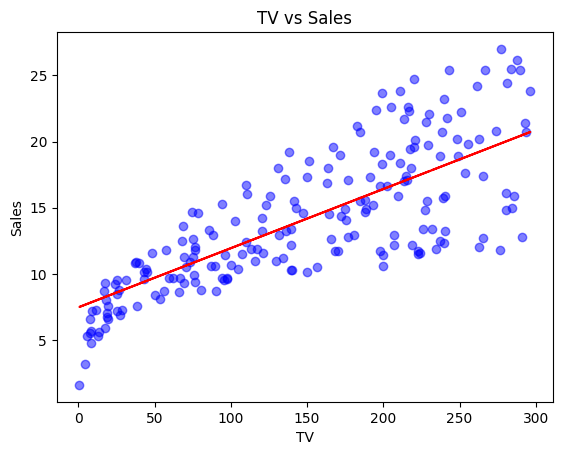

In [16]:
#Plot scatter plot

plt.scatter(df['TV'],y, color='blue', alpha=0.5)
plt.plot(df['TV'],rc.intercept_+rc.coef_[0]*df['TV']+rc.coef_[1]*df['Radio'].mean()+rc.coef_[2]*df['Newspaper'].mean(),color='red')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()



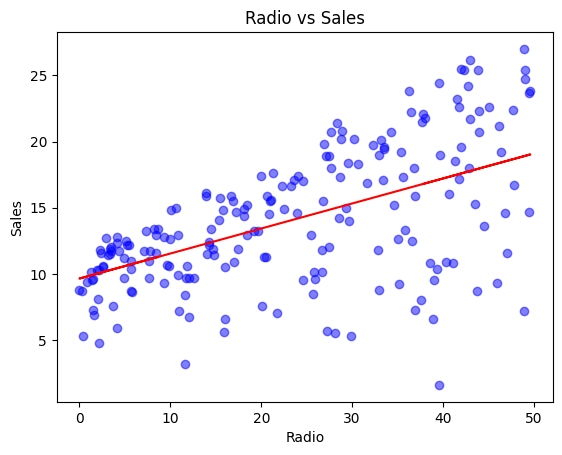

In [17]:
#Plot scatter plot

plt.scatter(df['Radio'],y, color='blue', alpha=0.5)
plt.plot(df['Radio'],rc.intercept_+rc.coef_[0]*df['TV'].mean()+rc.coef_[1]*df['Radio']+rc.coef_[2]*df['Newspaper'].mean(),color='red')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Radio vs Sales')
plt.show()



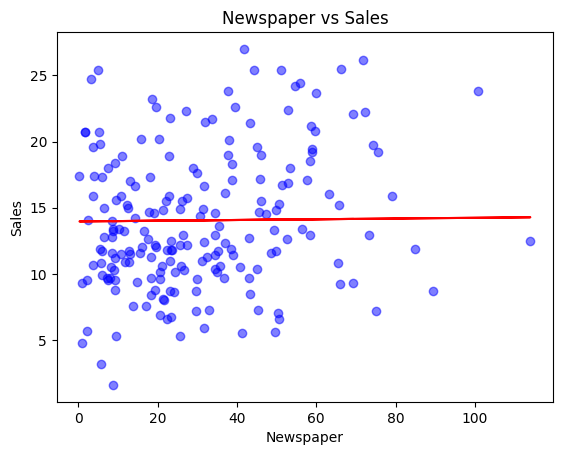

In [18]:
#Plot scatter plot

plt.scatter(df['Newspaper'],y, color='blue', alpha=0.5)
plt.plot(df['Newspaper'],rc.intercept_+rc.coef_[0]*df['TV'].mean()+rc.coef_[1]*df['Radio'].mean()+rc.coef_[2]*df['Newspaper'],color='red')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.title('Newspaper vs Sales')
plt.show()



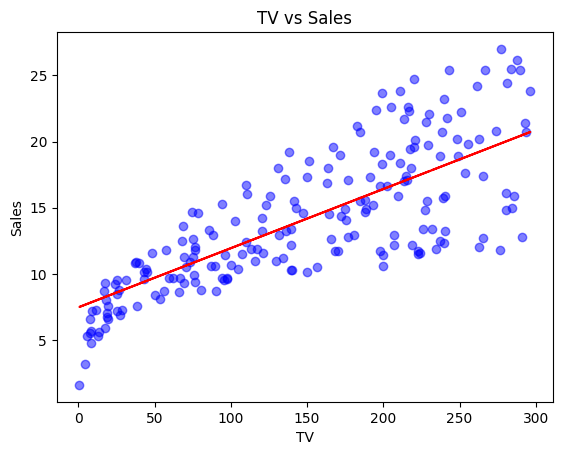

In [19]:
#Plot scatter plot

plt.scatter(df['TV'],y, color='blue', alpha=0.5)
plt.plot(df['TV'],rc.intercept_+rc.coef_[0]*df['TV']+rc.coef_[1]*df['Radio'].mean()+rc.coef_[2]*df['Newspaper'].mean(),color='red')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()



#IGNORE - TEST#

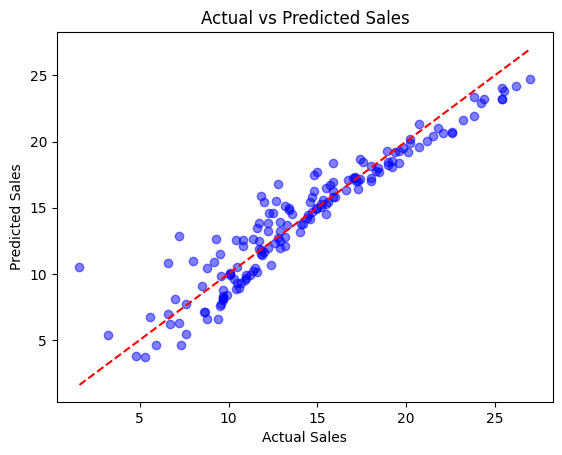

In [20]:
#Plot scatter plot

plt.scatter(Y_train, rc.predict(X_train), color='blue', alpha=0.5)
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()



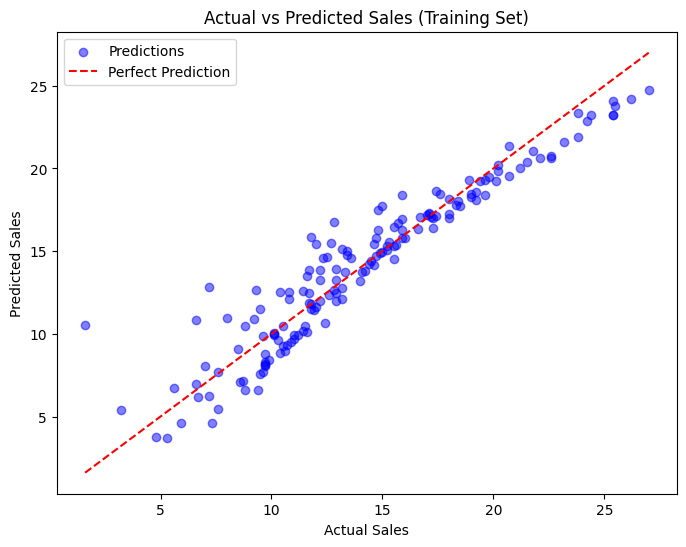

In [21]:
# Plot: Actual vs Predicted (standard evaluation plot)
plt.figure(figsize=(8, 6))
plt.scatter(Y_train, rc.predict(X_train), color='blue', alpha=0.5, label='Predictions')
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Training Set)')
plt.legend()
plt.show()

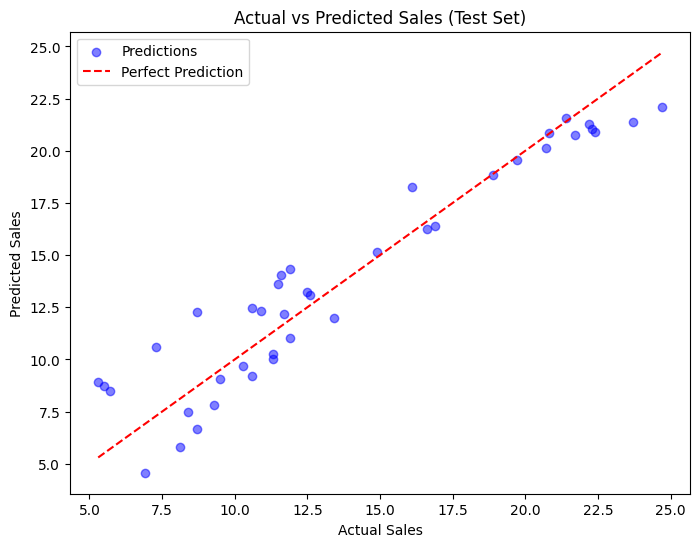

In [22]:
#Plot scatter plot

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, rc.predict(X_test), color='blue', alpha=0.5, label='Predictions')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Test Set)')
plt.legend()
plt.show()



In [23]:
Y_test

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    11.5
45     14.9
66      9.5
182     8.7
165    11.9
78      5.3
186    10.3
177    11.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65      9.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      10.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
Name: Sales, dtype: float64